<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Gear_Games3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

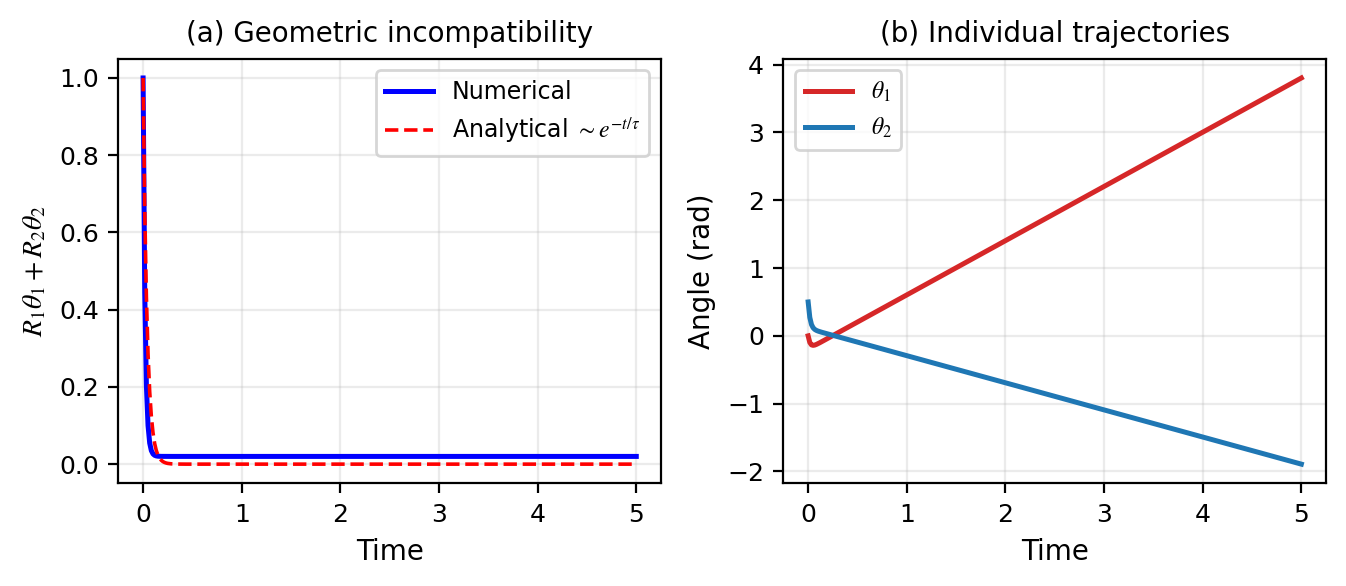

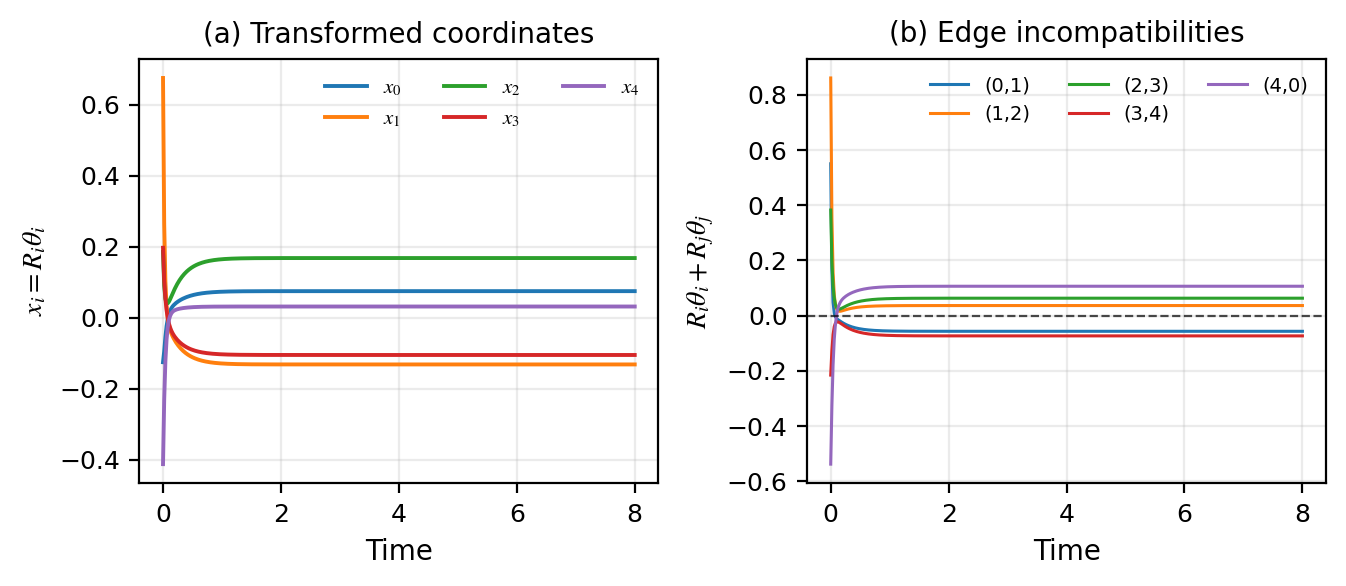

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==================== PRL-STYLE CONFIG ====================
plt.rcParams.update({
    'font.size': 9,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stix',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 200,
    'savefig.dpi': 600,
    'axes.linewidth': 0.8,
})

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# ====================== FIGURA 1: TWO GEARS ======================
def two_gear_dynamics(t, theta, R1, R2, w1, w2, k, gamma):
    theta1, theta2 = theta
    inc = R1*theta1 + R2*theta2
    return [w1 - gamma*k*R1*inc, w2 - gamma*k*R2*inc]

# Parameters
R1, R2 = 1.0, 2.0
w1, w2 = 1.0, 0.0
k, gamma = 10.0, 1.0
theta0 = [0.0, 0.5]
t_eval = np.linspace(0, 5, 300)

sol = solve_ivp(lambda t,y: two_gear_dynamics(t,y,R1,R2,w1,w2,k,gamma),
                (0, 5), theta0, t_eval=t_eval, rtol=1e-8)

inc = R1*sol.y[0] + R2*sol.y[1]
tau = 1 / (k * (R1**2 + R2**2)/2)
envelope = np.abs(inc[0]) * np.exp(-sol.t / tau)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.8, 3.0))

ax1.plot(sol.t, inc, 'b-', lw=1.8, label='Numerical')
ax1.plot(sol.t, envelope, 'r--', lw=1.3, label=r'Analytical $\sim e^{-t/\tau}$')
ax1.set_xlabel('Time')
ax1.set_ylabel(r'$R_1\theta_1 + R_2\theta_2$')
ax1.set_title('(a) Geometric incompatibility')
ax1.legend(fontsize=8.5)
ax1.grid(True, alpha=0.25)

ax2.plot(sol.t, sol.y[0], color=colors[3], lw=1.8, label=r'$\theta_1$')
ax2.plot(sol.t, sol.y[1], color=colors[0], lw=1.8, label=r'$\theta_2$')
ax2.set_xlabel('Time')
ax2.set_ylabel('Angle (rad)')
ax2.set_title('(b) Individual trajectories')
ax2.legend(fontsize=8.5)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig1_two_gear_dynamics.pdf', format='pdf')
plt.savefig('fig1_two_gear_dynamics.png', dpi=600)
plt.show()

# ====================== FIGURA 2: FIVE-AGENT NETWORK ======================
def network_dynamics(t, theta, R, omega, k_edges, gamma, edges):
    n = len(theta)
    dtheta = omega.copy()
    for i in range(n):
        incompat_sum = 0.0
        for j in edges[i]:
            incompat_sum += k_edges[(i,j)] * R[i] * (R[i]*theta[i] + R[j]*theta[j])
        dtheta[i] -= gamma * incompat_sum
    return dtheta

# Parameters
n = 5
R = np.array([1.0, 1.5, 0.8, 2.0, 1.2])
omega = np.array([0.5, -0.3, 0.8, -0.2, 0.4])
gamma = 1.0
edges = {0: [1,4], 1: [0,2], 2: [1,3], 3: [2,4], 4: [3,0]}
k_edges = {(i,j):10 for i in range(5) for j in edges[i]}

np.random.seed(42)
theta0_net = np.random.uniform(-0.5, 0.5, n)

sol_net = solve_ivp(lambda t,y: network_dynamics(t,y,R,omega,k_edges,gamma,edges),
                    (0, 8), theta0_net, t_eval=np.linspace(0,8,400), rtol=1e-8)

x_net = R[:, None] * sol_net.y

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.8, 3.0))

for i in range(n):
    ax1.plot(sol_net.t, x_net[i], lw=1.4, label=f'$x_{{{i}}}$')
ax1.set_xlabel('Time')
ax1.set_ylabel(r'$x_i = R_i \theta_i$')
ax1.set_title('(a) Transformed coordinates')
ax1.legend(ncol=3, fontsize=7.5, frameon=False)
ax1.grid(True, alpha=0.25)

edge_pairs = [(0,1),(1,2),(2,3),(3,4),(4,0)]
for (i,j) in edge_pairs:
    incomp = R[i]*sol_net.y[i] + R[j]*sol_net.y[j]
    ax2.plot(sol_net.t, incomp, lw=1.1, label=f'({i},{j})')

ax2.axhline(0, color='k', ls='--', lw=0.8, alpha=0.7)
ax2.set_xlabel('Time')
ax2.set_ylabel(r'$R_i\theta_i + R_j\theta_j$')
ax2.set_title('(b) Edge incompatibilities')
ax2.legend(ncol=3, fontsize=7, frameon=False)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig2_five_agent_network.pdf', format='pdf')
plt.savefig('fig2_five_agent_network.png', dpi=600)
plt.show()